# Plot Utils for DeepThermo

data for plots can be [downloaded](https://www.dropbox.com/s/eeqymgz2ihf6eyf/data.tar?dl=0)

In [1]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)
import matplotlib.cm as cmx
import matplotlib as mpl
import glob,os 
import pandas as pd
from sklearn.preprocessing import normalize, MinMaxScaler
from sklearn.metrics import accuracy_score
import matplotlib
%matplotlib inline

mpl.rc('lines', linewidth=2)
mpl.rc('axes', labelsize=16, titlesize=16)
mpl.rc('figure', titlesize=20)
mpl.rc('font', size=14)  # global font size
mpl.rc('legend', fontsize=14, fancybox=True)
mpl.rc('xtick.major', size=6)
mpl.rc('xtick.minor', size=4)
mpl.rcParams['font.size'] = 14.0


def set_tick_font_size(axes, font_size):
    def __set_axis_tick(axis):
        for tick in axis.xaxis.get_major_ticks():
            tick.label.set_fontsize(font_size)
        for tick in axis.yaxis.get_major_ticks():
            tick.label.set_fontsize(font_size)
        #for tick in axis.zaxis.get_major_ticks():
        #    tick.label.set_fontsize(font_size)
    if hasattr(axes, '__iter__'):
        for axis in axes:
            __set_axis_tick(axis)
    else:
        __set_axis_tick(axes)
        
def z_plot(z, plot_name):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    set_tick_font_size(ax, 20)

    ax.plot(z[0], z[1], marker="o", alpha=0.5)
    ax.set_xlabel("$z_1$", fontsize=24)
    ax.set_ylabel("$z_2$", fontsize=24)    
    plt.savefig(plot_name, format='png',dpi=300, bbox_inches='tight');
    
    
def tsne_plot(x_pred_encoded, y_train, plot_name, clabel="Temperature"):
    Dmax = y_train;
    [n,s] = np.histogram(Dmax, 11);
    d = np.digitize(Dmax, s);
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    
    set_tick_font_size(ax, 20)
    cmi = plt.get_cmap('jet');
    cNorm = mpl.colors.Normalize(vmin=min(Dmax), vmax=max(Dmax));
    scalarMap = mpl.cm.ScalarMappable(norm=cNorm, cmap=cmi);

    x = x_pred_encoded[:,0]
    y = x_pred_encoded[:,1]

    ax.scatter(x, y, c=scalarMap.to_rgba(Dmax), marker="o", s=1, alpha=0.5)
    ax.set_xlabel("$t_1$", fontsize=24)
    ax.set_ylabel("$t_2$", fontsize=24)
    scalarMap.set_array(Dmax);
    
    plt.savefig(plot_name, format='png',dpi=300, bbox_inches='tight');
    plt.show()
    plt.clf();


def scatter3d(x,y,z, cs, colorsMap='jet',clabel="RMSD($\AA$)", title="latent dim"):
    cm = plt.get_cmap(colorsMap)
    cNorm = matplotlib.colors.Normalize(vmin=min(cs), vmax=max(cs))
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cm)
    fig = plt.figure(figsize=(10,10))
    ax = Axes3D(fig)
    set_tick_font_size(ax, 20)
    ax.set_xticks([-6,-3,0,3,6])
    ax.set_yticks([-6,-3,0,3,6])
    ax.set_zticks([-6,-3,0,3,6])
    ax.scatter(x, y, z, c=scalarMap.to_rgba(cs))
    ax.set_xlabel("$z_1$",fontsize=24)
    ax.set_ylabel("$z_2$",fontsize=24) 
    ax.set_zlabel("$z_3$",fontsize=24)     
    scalarMap.set_array(cs)
    #cbaxes = fig.add_axes([0.1, 0.1, 0.8, 0.05]) 
    cbar = fig.colorbar(scalarMap, shrink=0.8, orientation="horizontal", pad=0) #orientation="vertical", pad=0) 
    cbar.set_label(label=clabel,fontsize=24)
    cbar.ax.tick_params(labelsize=16)
    ax.set_title(title, fontsize=28)
    plt.savefig('%s_latent_space_d3.png'%title,format='png',dpi=300, bbox_inches='tight')

    
def scatter2d(x,y,cs,colorsMap='jet', title="latent dim"):
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111)
    #ax.set_title("X vs Y AVG",fontsize=14)
    set_tick_font_size(ax, 32)
    ax.set_xlabel("$z_1$",fontsize=32)
    #ax.set_ylabel("$z_2$",fontsize=32)
    ax.grid(True,linestyle='-',color='0.75')
    cm = plt.get_cmap(colorsMap)
    cNorm = matplotlib.colors.Normalize(vmin=min(cs), vmax=max(cs))
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cm)
    # scatter with colormap mapping to z value
    ax.scatter(x,y,s=20,c=scalarMap.to_rgba(cs), marker = 'o',);
    ax.set_title(title, fontsize=34)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=5)
    plt.savefig('latent_space_d2.png',format='png',dpi=300, bbox_inches='tight')   
    
def plot_loss(folder='./', start=3):
    fig, ax = plt.subplots()
    set_tick_font_size(ax, 14)
    for file in glob.glob(os.path.join(folder, 'loss*')):
        loss = np.load(file)
        train_loss = loss['loss']
        val_loss = loss['val_loss']
        dim = file.split('-')[-1].split('.')[0]
        print(file,dim)
        epochs = list(range(1,train_loss.shape[0]+1))
        ax.plot(epochs[start:], train_loss[start:], label='train-%s'%dim, marker='o', markersize=5)
        ax.plot(epochs[start:], val_loss[start:], label='val-%s'%dim, marker='o', markersize=5)
    ax.set(xlabel='epochs', ylabel='loss',
           title='VAE training on MoNbTaW')
    leg = ax.legend(fontsize=10)
    leg.get_frame().set_linewidth(0.0)
    plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  """


In [35]:
def read_dblog(sys="summit", op="conv", prec="fp32"):
    fname = "db-logs/{}/log.{}.{}".format(sys, op, prec)
    nskip = 4 if sys == "summit" else 3
    raw = pd.read_csv(fname, delim_whitespace=True, skiprows=nskip, header=None, comment="-")
    if op == "rnn":
        if sys == "crusher":
            raw.columns = ["hidden_size", "batch_size", "time_steps", "algo", 
                           "fwd_time", "bwd_inputs_time", "bwd_params_time", "total_time"]
            #raw["precision"]
            raw = raw[:-1]
        else:
            raw.columns = ["algo", "hidden_size", "batch_size", "time_steps", 
                           "precision", "fwd_time", "bwd_inputs_time", "bwd_params_time"]            
            total_time = raw["fwd_time"] + raw["bwd_inputs_time"] + raw["bwd_params_time"]
            raw['total_time'] = total_time
        
    elif op == "conv":
        header = [ "w", "h", "c", "n", "k", "f_w", "f_h", "pad_w", "pad_h", "stride_w", 
                       "stride_h", "precision", "fwd_time", "bwd_inputs_time",  
                       "bwd_params_time", "total_time", "algo"]
        if sys == "crusher":
            raw.columns = [i for i in header if i != "precision"]
            raw = raw[:-1]
            raw['algo'] = raw['algo'].replace({"ConvolutionFwdAlgoImplicitGEMM":"GEMM",
                                             "ConvolutionFwdAlgoWinograd":"WINOGRAD",
                                              "ConvolutionFwdAlgoFFT":"FFT",
                                              "ConvolutionFwdAlgoGEMM":"GEMM"})
        elif sys == "summit":
            if 'infer' in fname:
                raw.columns = ["w", "h", "c", "n", "k", "f_w", "f_h", "pad_w", "pad_h", "stride_w",
                          "stride_h", "precision", "fwd_time", "algo"]   
                raw['algo'] = raw['algo'].replace({"IMPLICIT_GEMM":"GEMM",
                                             "WINOGRAD_NONFUSED":"WINOGRAD",
                                              "FFT_TILING":"FFT",
                                              "IMPLICIT_PRECOMP_GEMM":"GEMM"})                
            else:
                raw.columns = header 
                raw['algo'] = raw['algo'].replace({"IMPLICIT_GEMM":"GEMM",
                                             "WINOGRAD_NONFUSED":"WINOGRAD",
                                              "FFT_TILING":"FFT",
                                              "IMPLICIT_PRECOMP_GEMM":"GEMM"})
        else:
            raw.columns = ["w", "h", "c", "n", "k", "f_w", "f_h", "pad_w", "pad_h", "stride_w",
                          "stride_h", "precision", "fwd_time"]
    else:
        #raw.drop(columns=raw.columns[-1:], axis=1, inplace=True)
        header = [ "m", "n", "k", "a_t", "b_t", "precision", "total_time"]
        if sys == "summit":
            raw.columns = header   
        elif sys == "crusher":
            raw.columns = [i for i in header if i != "precision"]
        else:
            raw.columns = [ "m", "n", "k", "a_t", "b_t", "total_time", "GOPS"]
                  
    return raw 


flops = {}
for sys in ["summit", "crusher"]: #["summit", "spock", "a64fx"]:
    conv_df = read_dblog(sys=sys,op='conv',prec='fp32')
    conv_df = conv_df.loc[conv_df['algo']=='GEMM']
    print(conv_df)
    time = conv_df['fwd_time']*1e-6
    h = (conv_df['h'] + 2*conv_df['pad_h'] -conv_df['f_h'])/conv_df['stride_h'] + 1
    w = h #(conv_df['w'] + 2*conv_df['pad_w'] -conv_df['f_w'])/conv_df['stride_w'] + 1
    d = h 
    f_d = conv_df['f_h']
    flops[sys] = 2.0*h*w*d*conv_df['c']*conv_df['n']*conv_df['k']*conv_df['f_h']*conv_df['f_w']*f_d/time/1e12    #
flops

     w   h   c  n   k  f_w  f_h  pad_w  pad_h  stride_w  stride_h precision  \
0    2   2  64  1  64    3    3      1      1         2         2     float   
1    4   4  64  1  64    3    3      1      1         2         2     float   
2    6   6  64  1  64    3    3      1      1         2         2     float   
3    8   8  64  1  64    3    3      1      1         2         2     float   
4   16  16  64  1  64    3    3      1      1         2         2     float   
5   12  12  64  1  64    3    3      1      1         2         2     float   
6   24  24  64  1  64    3    3      1      1         2         2     float   
7   32  32  64  1  64    3    3      1      1         2         2     float   
8   32  32   4  1  64    3    3      1      1         2         2     float   
9   48  48   4  1  64    3    3      1      1         2         2     float   
10  64  64   4  1  64    3    3      1      1         2         2     float   

    fwd_time  bwd_inputs_time  bwd_params_time  tot

{'summit': 0     0.002215
 1     0.044883
 2     0.118541
 3     0.255132
 4     1.676971
 5     0.723127
 6     5.082353
 7     7.470573
 8     1.940598
 9     2.391735
 10    2.565146
 dtype: float64, 'crusher': 0     0.009822
 1     0.164571
 2     0.431057
 3     0.876321
 4     3.018547
 5     1.786549
 6     4.747253
 7     5.285033
 8     2.003198
 9     3.630312
 10    4.793455
 dtype: float64}

    Crusher    Summit
1  2.003198  1.940598
2  3.018547  1.676971
3  0.876321  0.255132
4  0.164571  0.044883


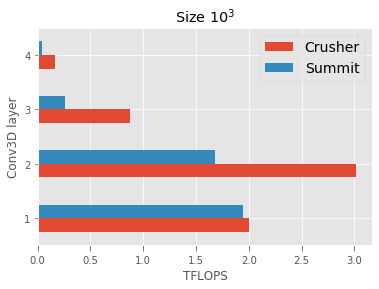

In [36]:
#model 1 
plt.rcParams.update({'font.size': 18})
data = {
        "Summit": [flops['summit'][8], flops['summit'][4],flops['summit'][3],flops['summit'][1] ],
        "Crusher": [flops['crusher'][8], flops['crusher'][4],flops['crusher'][3],flops['crusher'][1] ]
}

df = pd.DataFrame(data, columns=['Crusher','Summit'], index = ['1','2','3','4'])

print(df)
plt.style.use('ggplot')

df.plot.barh()

plt.title("Size 10$^3$")
plt.ylabel('Conv3D layer')
plt.xlabel('TFLOPS')


#plt.barh( features[sorted_idx], xgb.feature_importances_[sorted_idx], height=0.8, color='#ff7f0e',hatch='//')


plt.savefig('flops-1.png', dpi=300, bbox_inches='tight')


    Crusher    Summit
1  3.630312  2.391735
2  4.747253  5.082353
3  1.786549  0.723127
4  0.431057  0.118541


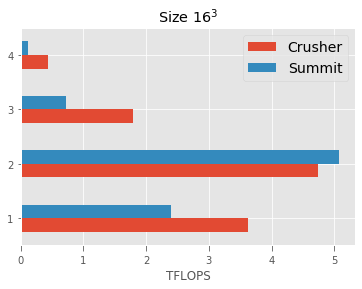

In [37]:
#model 2 
plt.rcParams.update({'font.size': 18})
data = {
        "Summit": [flops['summit'][9], flops['summit'][6],flops['summit'][5],flops['summit'][2] ],
        "Crusher": [flops['crusher'][9], flops['crusher'][6],flops['crusher'][5],flops['crusher'][2] ]
}

df = pd.DataFrame(data, columns=['Crusher','Summit'], index = ['1','2','3','4'])

print(df)
plt.style.use('ggplot')

df.plot.barh()

plt.title("Size 16$^3$")
#plt.ylabel('Conv3D layer')
plt.xlabel('TFLOPS')


#plt.barh( features[sorted_idx], xgb.feature_importances_[sorted_idx], height=0.8, color='#ff7f0e',hatch='//')


plt.savefig('flops-2.png', dpi=300, bbox_inches='tight')

    Crusher    Summit
1  4.793455  2.565146
2  5.285033  7.470573
3  3.018547  1.676971
4  0.876321  0.255132


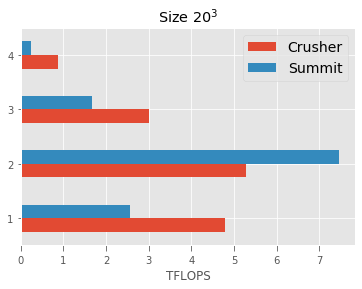

In [38]:
#model 3
plt.rcParams.update({'font.size': 18})
data = {
        "Summit": [flops['summit'][10], flops['summit'][7],flops['summit'][4],flops['summit'][3] ],
        "Crusher": [flops['crusher'][10], flops['crusher'][7],flops['crusher'][4],flops['crusher'][3] ]
}

df = pd.DataFrame(data, columns=['Crusher','Summit'], index = ['1','2','3','4'])

print(df)
plt.style.use('ggplot')

df.plot.barh()

plt.title("Size 20$^3$")
#plt.ylabel('Conv3D layer')
plt.xlabel('TFLOPS')


#plt.barh( features[sorted_idx], xgb.feature_importances_[sorted_idx], height=0.8, color='#ff7f0e',hatch='//')


plt.savefig('flops-3.png', dpi=300, bbox_inches='tight')

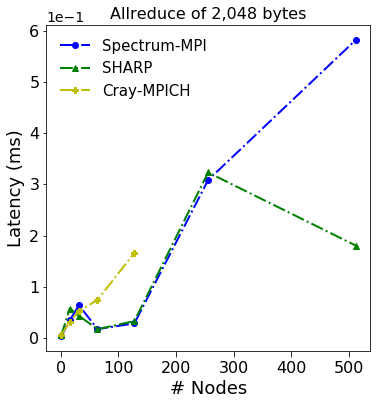

In [3]:

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))

data_c = pd.read_csv('perf/comm_crusher.csv', header=0)
data_s = pd.read_csv('perf/comm_summit.csv', header=0)

ax2.set_xlabel('# Nodes',fontdict=font)



#ax2 = ax.twinx()
ax2.plot(data_s['nodes'], data_s['SMPI'], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='Spectrum-MPI')
ax2.plot(data_s['nodes'], data_s['SHARP'], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='SHARP')
ax2.plot(data_c['nodes'], data_c['MPICH'], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='Cray-MPICH')

ax2.tick_params(axis='both', labelsize=16)


ax2.set_ylabel('Latency (ms)', fontdict=font)
ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15,loc='upper left')
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('comm.png', dpi=300, bbox_inches='tight')

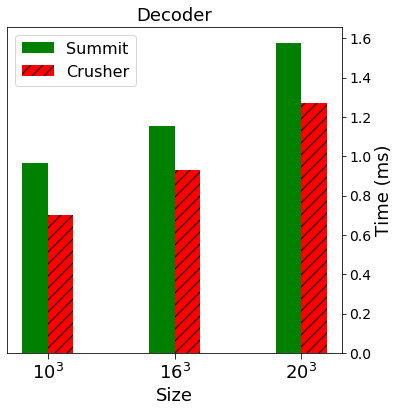

In [4]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

#mpl.rcParams['font.size'] = 18.0

data = pd.read_csv('perf/decoder.csv', header=0)

#print(data)
labels = ['10$^3$','16$^3$','20$^3$']
x = np.arange(len(labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(6,6))

rects1 = ax.bar(x - width/2, data["summit"], width, label='Summit', color='g')
rects2 = ax.bar(x + width/2, data["crusher"], width, label='Crusher', color='r', hatch='//')


# Add some text for labels, title and custom x-axis tick labels, etc.
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_ylabel('Time (ms)', fontdict=font)
ax.set_xlabel('Size', fontdict=font)
ax.set_title('Decoder', fontdict=font)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontdict=font)

ax.legend(loc='best', fontsize=16)

set_tick_font_size(ax, 18)

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


#autolabel(rects1)
#autolabel(rects2) 
#autolabel(rects3)
#autolabel(rects4) 
plt.savefig('decoder_tf.png',dpi=300, bbox_inches='tight')

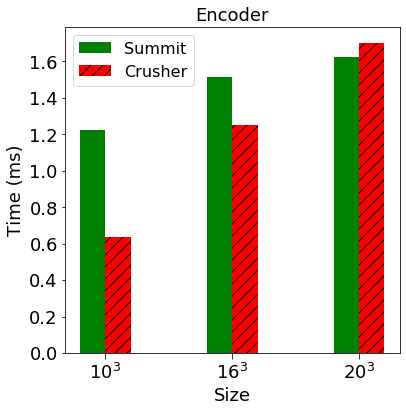

In [218]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }

data = pd.read_csv('perf/encoder.csv', header=0)

#print(data)
labels = ['10$^3$','16$^3$','20$^3$']
x = np.arange(len(labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(6,6))

rects1 = ax.bar(x - width/2, data["summit"], width, label='Summit', color='g')
rects2 = ax.bar(x + width/2, data["crusher"], width, label='Crusher', color='r', hatch='//')


# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Time (ms)', fontdict=font)
ax.set_xlabel('Size', fontdict=font)
ax.set_title('Encoder', fontdict=font)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontdict=font)
set_tick_font_size(ax, 18)
ax.legend(loc='best', fontsize=16)


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


#autolabel(rects1)
#autolabel(rects2) 
#autolabel(rects3)
#autolabel(rects4) 
plt.savefig('encoder_tf.png',dpi=300, bbox_inches='tight')

MoNbTaW/N10\loss.npz MoNbTaW/N10\loss


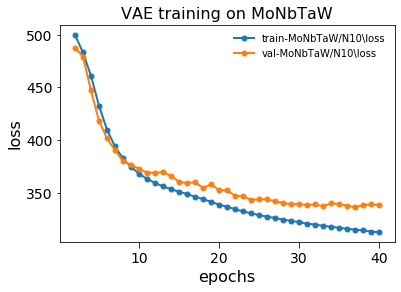

In [17]:
plot_loss('MoNbTaW/N10', 1)

(7680, 3) (7680,)
6.89952


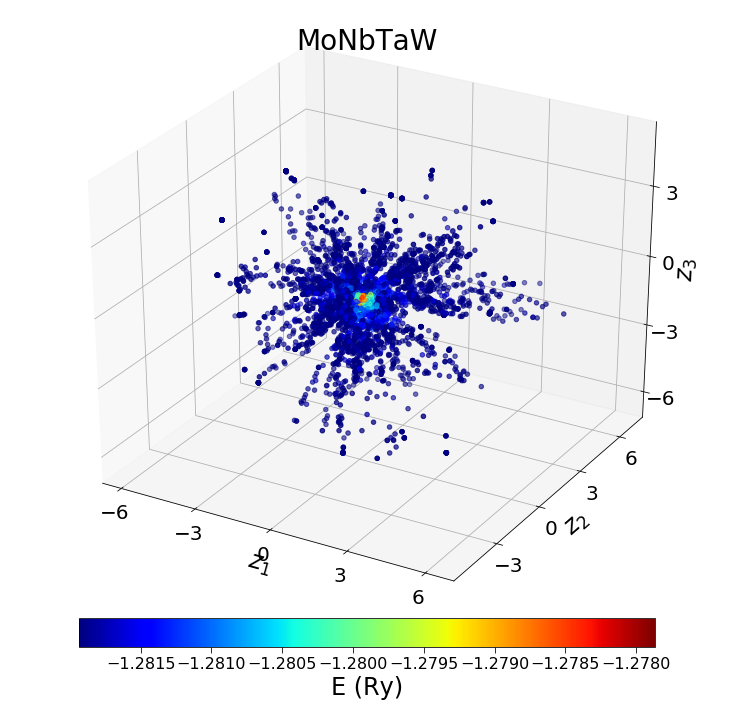

In [31]:
data_dir="MoNbTaW/N10"
label = np.load('%s/label_eng_val.npy'%data_dir)[:8000]
cm_emb = np.load('%s/vae_output-embeddings.npy'%data_dir, 'r')[:8000]
cm_emb = np.squeeze(cm_emb)
label = np.squeeze(label)
print(cm_emb.shape, label.shape)
start=0 
end=cm_emb.shape[0]
scatter3d(cm_emb[start:end,0], cm_emb[start:end,1], 
          cm_emb[start:end,2], label[start:end], clabel="E (Ry)", title="MoNbTaW")

print(cm_emb.max())

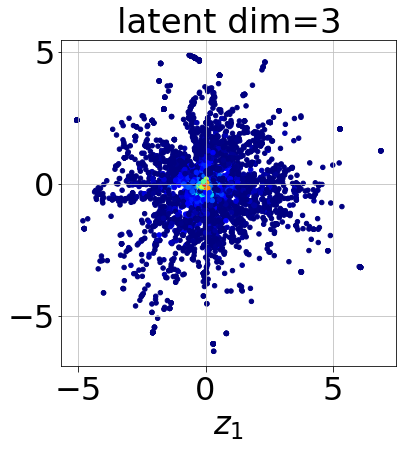

In [12]:
scatter2d(cm_emb[start:end,1], cm_emb[start:end,2], label[start:end], title="latent dim=3")

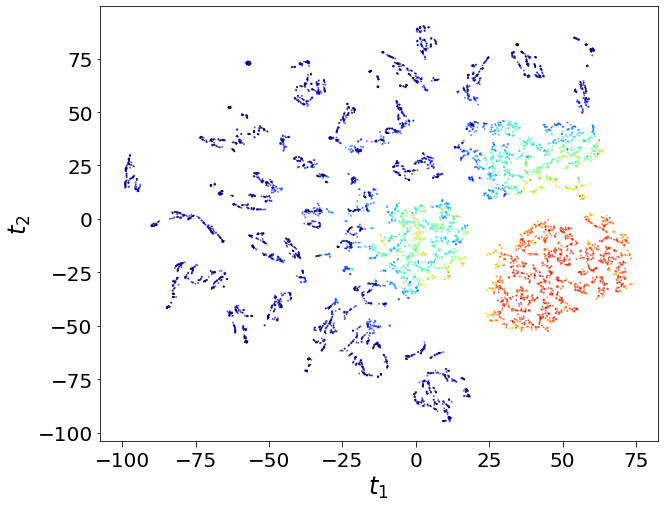

<Figure size 432x288 with 0 Axes>

In [38]:
data_dir="MoNbTaW/N10"
X_emb = np.load('%s/encoded_TSNE_2D.npy'%data_dir)
label = np.load('%s/label_eng_val.npy'%data_dir)
X_emb = np.squeeze(X_emb)
label = np.squeeze(label)
tsne_plot(X_emb, label, "MoNbTaW_vae_tsne_N10.png")

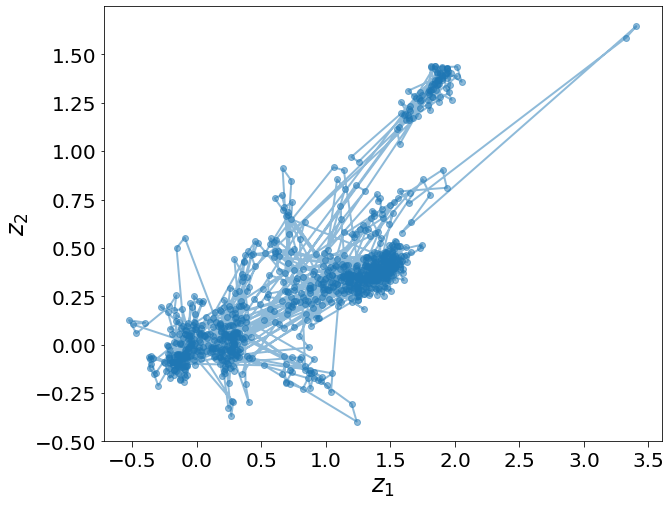

In [60]:
data_dir="MoNbTaW/N10"
z = pd.read_csv("%s/z.dat"%data_dir, header=None)
z_plot(z[:1000], "MoNbTaW_z.png")

# MoNbTaVW

MoNbTaVW\loss.npz MoNbTaVW\loss


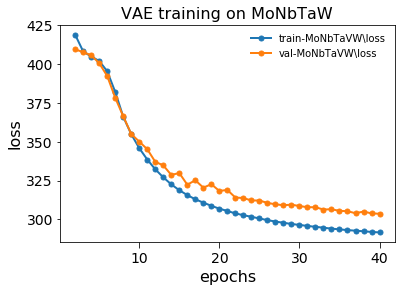

In [16]:
plot_loss('MoNbTaVW', 1)

(7680, 3) (7680,)
4.355851


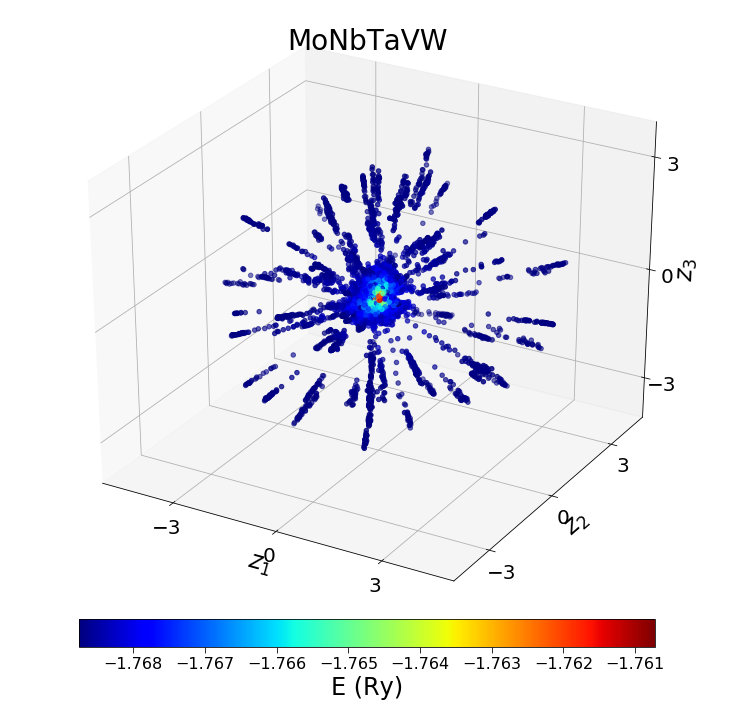

In [33]:
data_dir="MoNbTaVW"
label = np.load('%s/label_eng_val.npy'%data_dir)[:8000]
cm_emb = np.load('%s/vae_output-embeddings.npy'%data_dir, 'r')[:8000]
cm_emb = np.squeeze(cm_emb)
label = np.squeeze(label)
print(cm_emb.shape, label.shape)
start=0 
end=cm_emb.shape[0]
scatter3d(cm_emb[start:end,0], cm_emb[start:end,1], 
          cm_emb[start:end,2], label[start:end], clabel="E (Ry)", title="MoNbTaVW")

print(cm_emb.max())

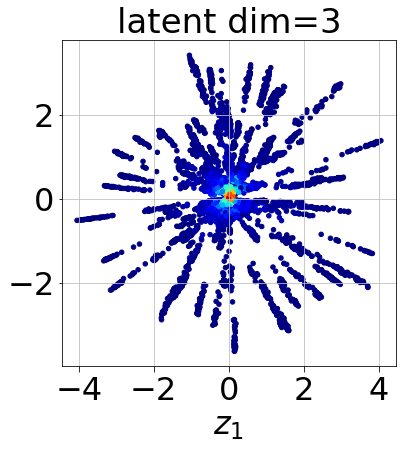

In [19]:
scatter2d(cm_emb[start:end,1], cm_emb[start:end,2], label[start:end], title="latent dim=3")

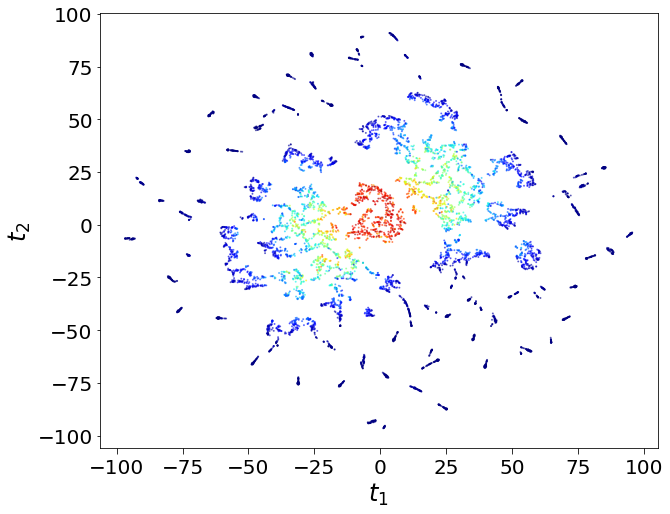

<Figure size 432x288 with 0 Axes>

In [39]:
data_dir="MoNbTaVW"
X_emb = np.load('%s/encoded_TSNE_2D.npy'%data_dir)
label = np.load('%s/label_eng_val.npy'%data_dir)
X_emb = np.squeeze(X_emb)
label = np.squeeze(label)
tsne_plot(X_emb, label, "MoNbTaVW_vae_tsne_N10.png")

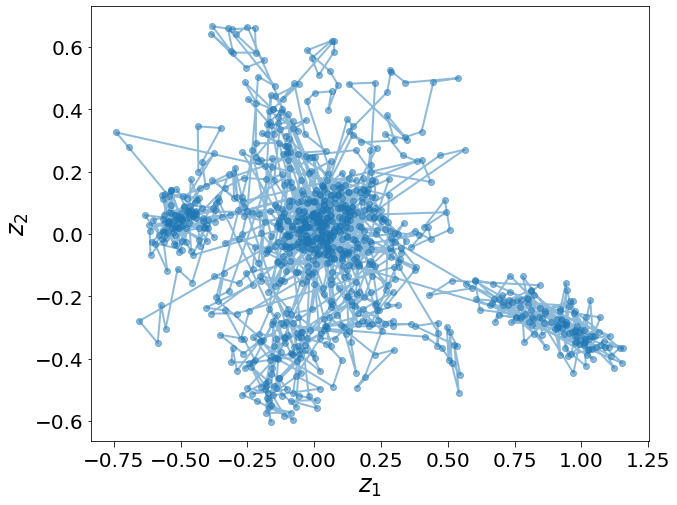

In [59]:
data_dir="MoNbTaVW"
z = pd.read_csv("%s/z.dat"%data_dir, header=None)
z_plot(z[:1000], "MoNbTaVW_z.png")

# MoNbTaTiW

MoNbTaTiW\loss.npz MoNbTaTiW\loss


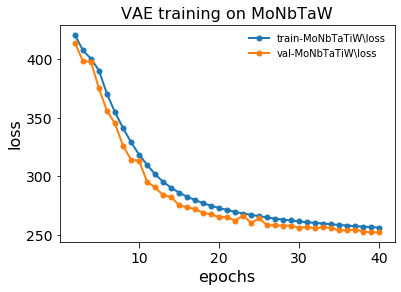

In [21]:
plot_loss('MoNbTaTiW', 1)

(7680, 3) (7680,)
4.265606


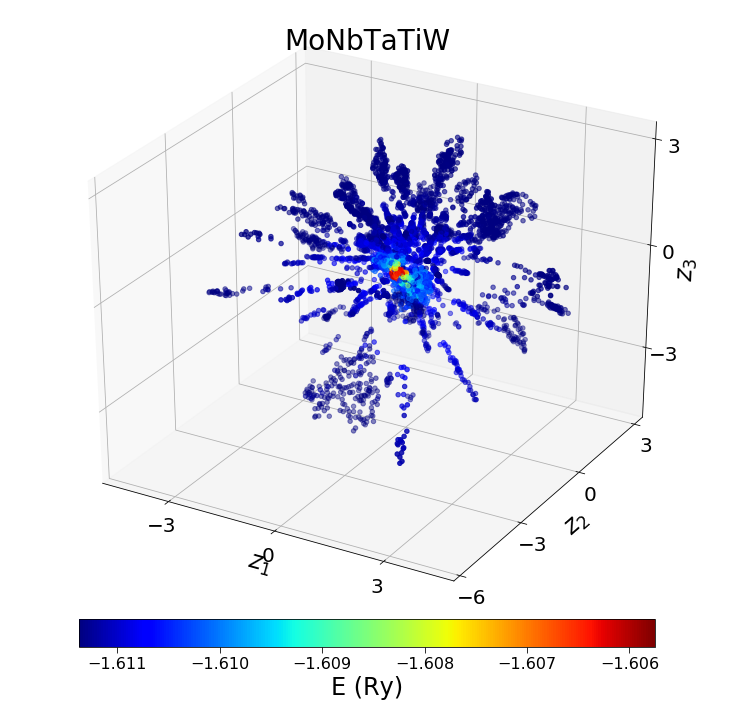

In [34]:
data_dir="MoNbTaTiW"
label = np.load('%s/label_eng_val.npy'%data_dir)[:8000]
cm_emb = np.load('%s/vae_output-embeddings.npy'%data_dir, 'r')[:8000]
cm_emb = np.squeeze(cm_emb)
label = np.squeeze(label)
print(cm_emb.shape, label.shape)
start=0 
end=cm_emb.shape[0]
scatter3d(cm_emb[start:end,0], cm_emb[start:end,1], 
          cm_emb[start:end,2], label[start:end], clabel="E (Ry)", title="MoNbTaTiW")

print(cm_emb.max())

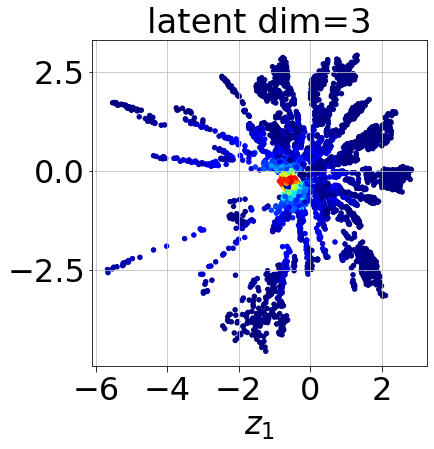

In [23]:
scatter2d(cm_emb[start:end,1], cm_emb[start:end,2], label[start:end], title="latent dim=3")

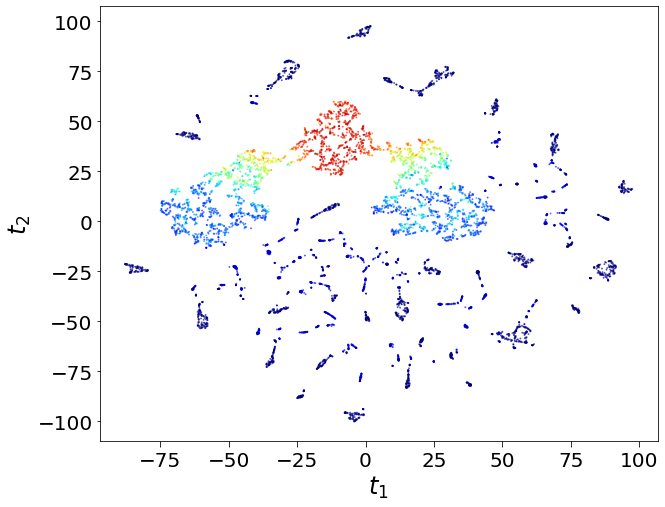

<Figure size 432x288 with 0 Axes>

In [40]:
data_dir="MoNbTaTiW"
X_emb = np.load('%s/encoded_TSNE_2D.npy'%data_dir)
label = np.load('%s/label_eng_val.npy'%data_dir)
X_emb = np.squeeze(X_emb)
label = np.squeeze(label)
tsne_plot(X_emb, label, "MoNbTaTiW_vae_tsne_N10.png")

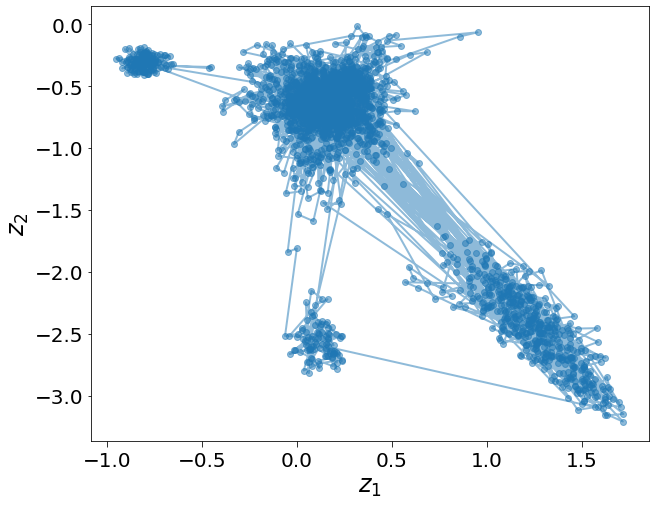

In [62]:
data_dir="MoNbTaTiW"
z = pd.read_csv("%s/z.dat"%data_dir, header=None)
z_plot(z[:3000], "MoNbTaTiW_z.png")

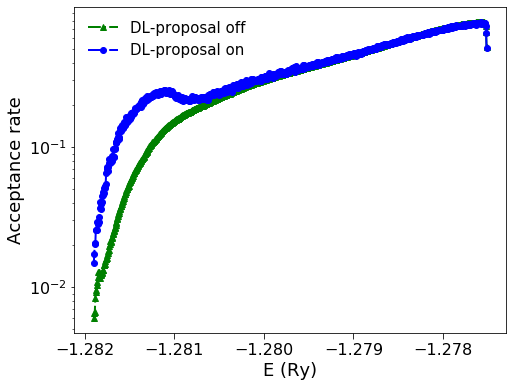

In [20]:

acc_on = pd.read_csv("acc/on.dat", header=None, delim_whitespace=True, comment='#')
acc_off = pd.read_csv("acc/off.dat", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(8,6))


ax2.set_xlabel('E (Ry)',fontdict=font)

ax2.plot(acc_off.iloc[:,0], acc_off.iloc[:,3], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='DL-proposal off')
ax2.plot(acc_on.iloc[:,0], acc_on.iloc[:,3], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='DL-proposal on')


#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('Acceptance rate', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

ax2.set_yscale('log')

#plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
#plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('acc.png', dpi=300, bbox_inches='tight')

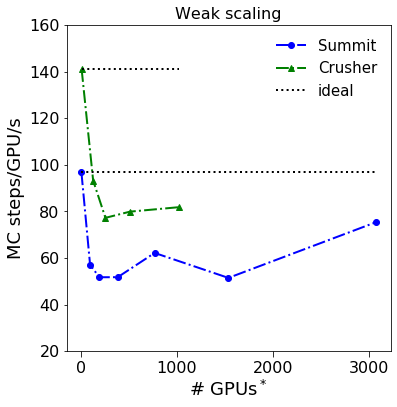

In [10]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


data_s = pd.read_csv('perf/weak-summit.csv', header=0)
data_c = pd.read_csv('perf/weak-crusher.csv', header=0)

ideals_s = [ data_s['steps'][0] for n in data_s['ngpus'] ]
ideals_c = [ data_c['steps'][0] for n in data_c['ngpus'] ]

ax2.set_xlabel('# GPUs$^*$',fontdict=font)


#ax2 = ax.twinx()
ax2.plot(data_s['ngpus'], data_s['steps'], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='Summit')
ax2.plot(data_c['ngpus'], data_c['steps'], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='Crusher')


ax2.plot(data_s['ngpus'], ideals_s, color='k', linestyle='dotted')
ax2.plot(data_c['ngpus'], ideals_c, color='k', linestyle='dotted', label='ideal')

ax2.tick_params(axis='both', labelsize=16)


ax2.set_ylabel('MC steps/GPU/s', fontdict=font)
ax2.set_title('Weak scaling')
ax2.tick_params(axis='both', labelsize=16)
#ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))
#ax2.yaxis.set_label_position("right")
#ax2.yaxis.tick_right()
ax2.set_ylim((20,160))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15,loc='upper right')
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('throughput.png', dpi=300, bbox_inches='tight')

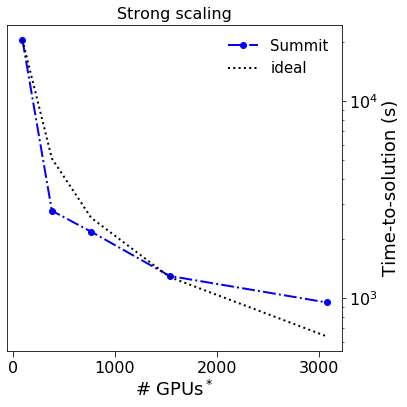

In [13]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))

data_s = pd.read_csv('perf/strong-summit.csv', header=0)

ideals_s = [ data_s['sec'][0]*data_s['ngpus'][0]/n for n in data_s['ngpus'] ]

ax2.set_xlabel('# GPUs$^*$',fontdict=font)

#ax2 = ax.twinx()
ax2.plot(data_s['ngpus'], data_s['sec'], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='Summit')


ax2.plot(data_s['ngpus'], ideals_s, color='k', linestyle='dotted', label='ideal')

ax2.tick_params(axis='both', labelsize=16)


ax2.set_ylabel('Time-to-solution (s)', fontdict=font)
ax2.set_title('Strong scaling')
ax2.tick_params(axis='both', labelsize=16)
#ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_yscale("log")


#plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15,loc='upper right')
leg.get_frame().set_linewidth(0.0)
#plt.ticklabel_format(useOffset=False)
#plt.subplots_adjust(left=0.15)
fig.savefig('time-to-solution.png', dpi=300, bbox_inches='tight')

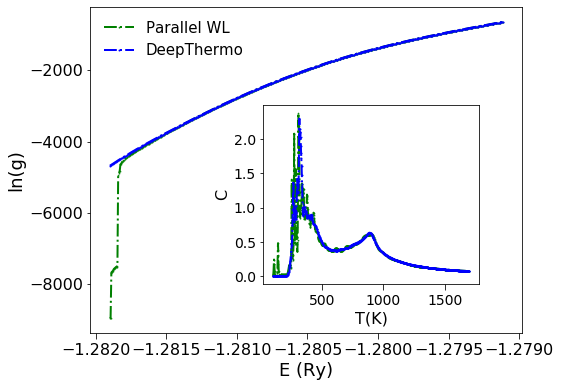

In [66]:
stat_16_on = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16_on = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')


stat_16_off = pd.read_csv("acc/therm-L16-off-n64.dat", header=None, delim_whitespace=True)
g_16_off = pd.read_csv("acc/g-L16-off-n64.dat", header=None, delim_whitespace=True, comment='#')

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(8,6))


#ax1 = ax2.twinx()
#ax1.spines['right'].set_color('r')

ax2.set_xlabel('E (Ry)',fontdict=font)

start=-300
ax2.plot(g_16_off.iloc[:start,0], g_16_off.iloc[:start,1], linestyle='-.', marker='^', color='g', markersize=1,
        markerfacecolor='g',markeredgecolor='g', label='Parallel WL')
ax2.plot(g_16_on.iloc[:start,0], g_16_on.iloc[:start,1], linestyle='-.', marker='o', color='b', markersize=1,
        markerfacecolor='b',markeredgecolor='b', label='DeepThermo')



end = 800
ax1 = plt.axes([0,0,1,1])
# Manually set the position and relative size of the inset axes within ax1
ip = InsetPosition(ax2, [0.4,0.15,0.5,0.55])
ax1.set_axes_locator(ip)

ax1.plot(stat_16_off.iloc[:end,0], stat_16_off.iloc[:end,2], linestyle='-.', marker='^', color='g', markersize=1,
        markerfacecolor='g',markeredgecolor='g')
ax1.plot(stat_16_on.iloc[:end,0], stat_16_on.iloc[:end,2], linestyle='-.', marker='o', color='b', markersize=1,
        markerfacecolor='b',markeredgecolor='b')
ax1.set_ylabel("C")
ax1.set_xlabel("T(K)")

#ax2.plot((13,18), (382, 410), color='black', linewidth=0.5, linestyle='dashed')

ax2.set_ylabel('ln(g)', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='x', style='sci', scilimits=(0,3))

#ax2.set_yscale('log')

#plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
#plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('compare2.png', dpi=300, bbox_inches='tight')

# Production

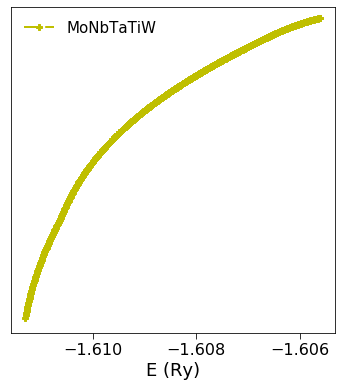

In [19]:
stat = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base = pd.read_csv("MoNbTaW/baseline/stat0.dat", header=None, delim_whitespace=True)

stat_V = pd.read_csv("MoNbTaVW/prod/therm.dat", header=None, delim_whitespace=True)
g_V = pd.read_csv("MoNbTaVW/prod/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base_V = pd.read_csv("MoNbTaVW/baseline/stat0.dat", header=None, delim_whitespace=True)

stat_Ti = pd.read_csv("MoNbTaTiW/prod/therm.dat", header=None, delim_whitespace=True)
g_Ti = pd.read_csv("MoNbTaTiW/prod/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base_Ti = pd.read_csv("MoNbTaTiW/baseline/stat0.dat", header=None, delim_whitespace=True)


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('E (Ry)',fontdict=font)

#ax2.plot(g.iloc[:,0], g.iloc[:,1], linestyle='-.', marker='o', color='b', 
#        markerfacecolor='b',markeredgecolor='b', label='MoNbTaW')
#ax2.plot(g_V.iloc[:,0], g_V.iloc[:,1], linestyle='-.', marker='^', color='g', 
#        markerfacecolor='g',markeredgecolor='g', label='MoNbTaVW')
ax2.plot(g_Ti.iloc[:,0], g_Ti.iloc[:,1], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='MoNbTaTiW')

#ax2.tick_params(axis='both', labelsize=16)

#ax2.set_ylabel('ln(g)', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

ax2.set_ylim((-1450, 50))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('g_Ti.png', dpi=300, bbox_inches='tight')



         0       1         2        3         4         5           6
0      100 -1.2819  0.007573 -1.28190  0.000000  4.063010  326.514000
1      102 -1.2819  0.008841 -1.28188 -0.024374  4.027700  328.741000
2      104 -1.2819  0.010302 -1.28187 -0.047781  3.987710  331.669000
3      106 -1.2819  0.011983 -1.28185 -0.070271  3.942710  335.209000
4      108 -1.2819  0.013917 -1.28183 -0.091890  3.892360  339.246000
...    ...     ...       ...      ...       ...       ...         ...
1447  2994 -1.2779  0.023146 -1.27939  0.078905  0.203530    0.005493
1448  2996 -1.2779  0.023116 -1.27939  0.078892  0.203527    0.005488
1449  2998 -1.2779  0.023086 -1.27939  0.078880  0.203523    0.005483
1450  3000 -1.2779  0.023056 -1.27939  0.078867  0.203520    0.005478
1451  3002 -1.2779  0.023026 -1.27940  0.078855  0.203517    0.005473

[1452 rows x 7 columns]


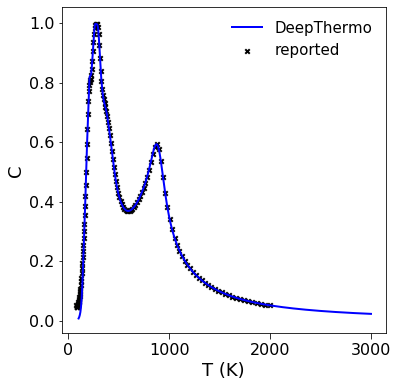

In [17]:
stat = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base = pd.read_csv("MoNbTaW/baseline/stat0.dat", header=None, delim_whitespace=True)

stat_V = pd.read_csv("MoNbTaVW/prod/therm.dat", header=None, delim_whitespace=True)
g_V = pd.read_csv("MoNbTaVW/prod/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base_V = pd.read_csv("MoNbTaVW/baseline/stat0.dat", header=None, delim_whitespace=True)

stat_Ti = pd.read_csv("MoNbTaTiW/prod/therm.dat", header=None, delim_whitespace=True)
g_Ti = pd.read_csv("MoNbTaTiW/prod/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')
stat_base_Ti = pd.read_csv("MoNbTaTiW/baseline/stat0.dat", header=None, delim_whitespace=True)


print(stat)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('T (K)',fontdict=font)

ax2.scatter(stat_base.iloc[50:,0], stat_base.iloc[50:,2], marker='x', color='k', 
        s=20, alpha=1.0, label='reported')
ax2.plot(stat.iloc[:,0], stat.iloc[:,2], linestyle='-', color='b', label='DeepThermo')

#ax2.scatter(stat_base_V.iloc[50:,0], stat_base_V.iloc[50:,2], marker='x', color='k', 
#        s=20, alpha=1.0, label='reported')
#ax2.plot(stat_V.iloc[:,0], stat_V.iloc[:,2], linestyle='-', color='g', label='DeepThermo')

#ax2.scatter(stat_base_Ti.iloc[50:,0], stat_base_Ti.iloc[50:,2], marker='x', color='k', 
#        s=20, alpha=1.0, label='reported')
#ax2.plot(stat_Ti.iloc[:,0], stat_Ti.iloc[:,2], linestyle='-', color='y', label='DeepThermo')


#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('C', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

#ax2.set_yscale('log')

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('C.png', dpi=300, bbox_inches='tight')

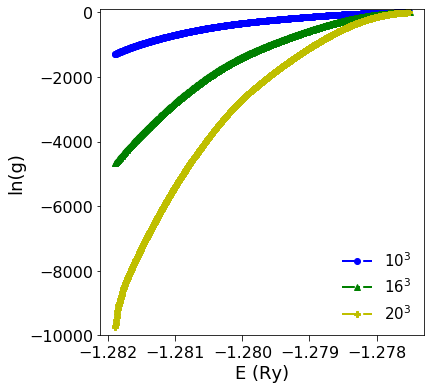

In [13]:
stat_10 = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g_10 = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_16 = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16 = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_20 = pd.read_csv("MoNbTaW/prod/N20/therm.dat", header=None, delim_whitespace=True)
g_20 = pd.read_csv("MoNbTaW/prod/N20/g20.txt", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('E (Ry)',fontdict=font)

ax2.plot(g_10.iloc[:,0], g_10.iloc[:,1], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='$10^3$')
ax2.plot(g_16.iloc[:,0], g_16.iloc[:,1], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='$16^3$')
ax2.plot(g_20.iloc[:,0], g_20.iloc[:,1], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='$20^3$')

#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('ln(g)', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

ax2.set_ylim((-10000, 100))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('g_all.png', dpi=300, bbox_inches='tight')



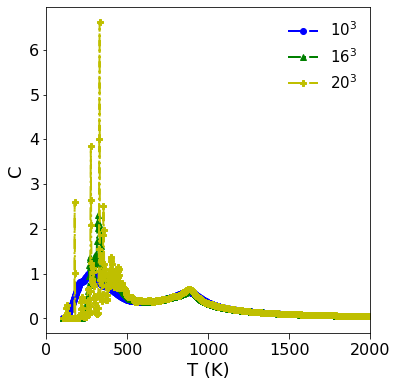

In [14]:
stat_10 = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g_10 = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_16 = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16 = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_20 = pd.read_csv("MoNbTaW/prod/N20/stat.txt", header=None, delim_whitespace=True)
g_20 = pd.read_csv("MoNbTaW/prod/N20/g20.txt", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('T (K)',fontdict=font)

ax2.plot(stat_10.iloc[:,0], stat_10.iloc[:,2], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='$10^3$')
ax2.plot(stat_16.iloc[:,0], stat_16.iloc[:,2], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='$16^3$')
ax2.plot(stat_20.iloc[:,0], stat_20.iloc[:,2], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='$20^3$')

#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('C', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

#ax2.set_ylim((-10000, 100))
ax2.set_xlim((0, 2000))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('C_all.png', dpi=300, bbox_inches='tight')

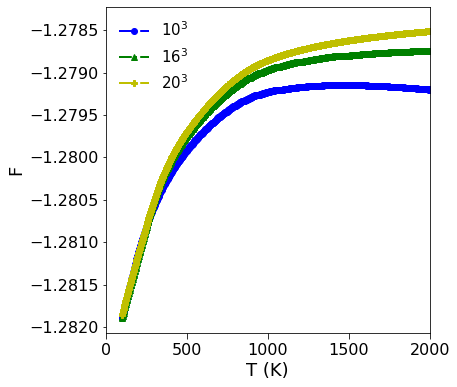

In [15]:
stat_10 = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g_10 = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_16 = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16 = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_20 = pd.read_csv("MoNbTaW/prod/N20/stat.txt", header=None, delim_whitespace=True)
g_20 = pd.read_csv("MoNbTaW/prod/N20/DOS_H_iter023.dat", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('T (K)',fontdict=font)


ax2.plot(stat_10.iloc[:,0], stat_10.iloc[:,3], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='$10^3$')
ax2.plot(stat_16.iloc[:,0], stat_16.iloc[:,3], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='$16^3$')
ax2.plot(stat_20.iloc[:,0], stat_20.iloc[:,3], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='$20^3$')

#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('F', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,3))

#ax2.set_ylim((-10000, 100))
ax2.set_xlim((0, 2000))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('F_all.png', dpi=300, bbox_inches='tight')

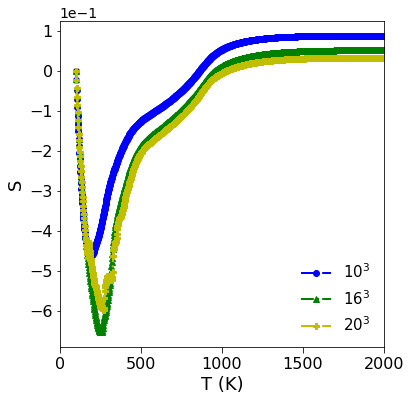

In [16]:
stat_10 = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g_10 = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_16 = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16 = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_20 = pd.read_csv("MoNbTaW/prod/N20/stat.txt", header=None, delim_whitespace=True)
g_20 = pd.read_csv("MoNbTaW/prod/N20/DOS_H_iter023.dat", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('T (K)',fontdict=font)

ax2.plot(stat_10.iloc[:,0], stat_10.iloc[:,4], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='$10^3$')
ax2.plot(stat_16.iloc[:,0], stat_16.iloc[:,4], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='$16^3$')
ax2.plot(stat_20.iloc[:,0], stat_20.iloc[:,4], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='$20^3$')

#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('S', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

#ax2.set_ylim((-10000, 100))
ax2.set_xlim((0, 2000))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('S_all.png', dpi=300, bbox_inches='tight')

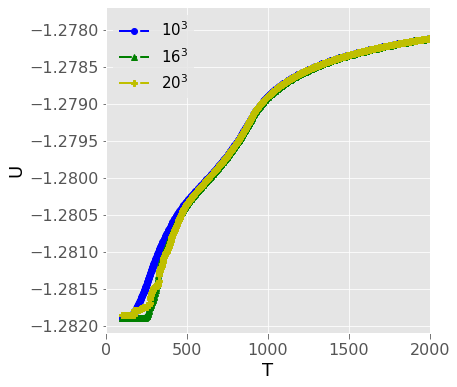

In [135]:
stat_10 = pd.read_csv("MoNbTaW/prod/N10/therm.dat", header=None, delim_whitespace=True)
g_10 = pd.read_csv("MoNbTaW/prod/N10/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_16 = pd.read_csv("MoNbTaW/prod/N16/therm.dat", header=None, delim_whitespace=True)
g_16 = pd.read_csv("MoNbTaW/prod/N16/DOS_H_iter025.dat", header=None, delim_whitespace=True, comment='#')

stat_20 = pd.read_csv("MoNbTaW/prod/N20/stat.txt", header=None, delim_whitespace=True)
g_20 = pd.read_csv("MoNbTaW/prod/N20/DOS_H_iter023.dat", header=None, delim_whitespace=True, comment='#')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
        }
fig, ax2 = plt.subplots(figsize=(6,6))


ax2.set_xlabel('T',fontdict=font)

ax2.plot(stat_10.iloc[:,0], stat_10.iloc[:,1], linestyle='-.', marker='o', color='b', 
        markerfacecolor='b',markeredgecolor='b', label='$10^3$')
ax2.plot(stat_16.iloc[:,0], stat_16.iloc[:,1], linestyle='-.', marker='^', color='g', 
        markerfacecolor='g',markeredgecolor='g', label='$16^3$')
ax2.plot(stat_20.iloc[:,0], stat_20.iloc[:,1], linestyle='-.', marker='P', color='y', 
        markerfacecolor='y',markeredgecolor='y', label='$20^3$')

#ax2.tick_params(axis='both', labelsize=16)

ax2.set_ylabel('U', fontdict=font)
#ax2.set_title('Allreduce of 2,048 bytes')
ax2.tick_params(axis='both', labelsize=16)
#ax2.axes.yaxis.set_ticks([])
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,5))

#ax2.set_ylim((-10000, 100))
ax2.set_xlim((0, 2000))

plt.ticklabel_format(axis='both',useOffset=False)
leg = ax2.legend(fontsize=15)
leg.get_frame().set_linewidth(0.0)
plt.ticklabel_format(useOffset=False)
plt.subplots_adjust(left=0.15)
fig.savefig('U_all.png', dpi=300, bbox_inches='tight')